# 01. Exploratory analysis and data cleansing

This notebook examines the raw inputs, verifies that timestamps and joins
are exactly right, justifies the cleansing decisions and writes the
processed train, validation and test splits consumed by every model
notebook. `scripts/build_dataset.py` mirrors the build steps headlessly.

The data are NSW1 operational demand actuals from NEMWeb (half-hourly),
ERA5 reanalysis weather and archived ECMWF IFS day-ahead forecasts from
Open-Meteo (hourly, interpolated onto the half-hourly grid). Everything is
stored and modelled in UTC with period-start timestamps; plots are shown in
AEST, the NEM market time. Weather data by
[Open-Meteo](https://open-meteo.com/) (CC BY 4.0).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from nemforecastdemand.config import load_config
from nemforecastdemand.data import weather
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.features.calendar import holiday_flag
from nemforecastdemand.features.preprocessing import build_panel, half_hourly_grid
from nemforecastdemand.plotting import (
    DISPLAY_TZ,
    LOCAL_TZ,
    display_index,
    format_date_axis,
    palette,
    plot_clock_profile,
    save_figure,
    setup_style,
)
from nemforecastdemand.splits import chronological_split, split_summary

setup_style()
cfg = load_config()

In [2]:
demand = (
    pl.read_parquet(cfg.paths.interim / "demand.parquet").to_pandas().set_index("ts")["demand_mw"]
)
era5 = weather.load_raw(cfg.paths.raw / "weather" / "era5.parquet")
forecast = weather.load_raw(cfg.paths.raw / "weather" / "forecast.parquet")
demand.describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
demand_mw,18096.0,7633.15987,1571.372589,2848.0,6659.0,7511.0,8523.0,13204.0


## Timestamp and timezone audit

Three conventions interact here and each is a classic source of silent
misalignment, so they are verified rather than assumed.

1. AEMO publishes half hours stamped with their **ending** time in market
   time (AEST, a fixed UTC+10 with no daylight saving). The data layer
   shifts these to period-start stamps and converts to UTC.
2. Open-Meteo series were requested in UTC directly.
3. NSW behaviour follows the **local Sydney clock**, which moves against
   both UTC and market time at daylight-saving transitions.

First, the grid itself: the demand series should cover every half hour of
the window exactly once.

In [3]:
grid = half_hourly_grid(demand.index[0], demand.index[-1])
audit = pd.DataFrame(
    {
        "expected half hours": [len(grid)],
        "present": [len(demand)],
        "missing": [len(grid.difference(demand.index))],
        "duplicates": [int(demand.index.duplicated().sum())],
        "first (AEST)": [display_index(demand.index[:1])[0]],
        "last (AEST)": [display_index(demand.index[-1:])[0]],
    }
)
audit

,expected half hours,present,missing,duplicates,first (AEST),last (AEST)
0,18096,18096,0,0,2025-05-18 00:00:00+10:00,2026-05-29 23:30:00+10:00


The grid is complete and duplicate-free, and the window runs from market
midnight to market midnight as intended.

### The daily shape moves with the local clock, not the market clock

Market time has no daylight saving but Sydney does. If demand is profiled
against the market clock, the entire daily shape should jump by an hour
when DST begins. The four weeks either side of the October 2025 transition
make the point cleanly, and re-profiling against the local clock should
remove the jump. This matters for modelling: seasonal features built on the
market clock would smear the morning and evening ramps for half the year,
so every calendar feature in this project is computed from the local clock.

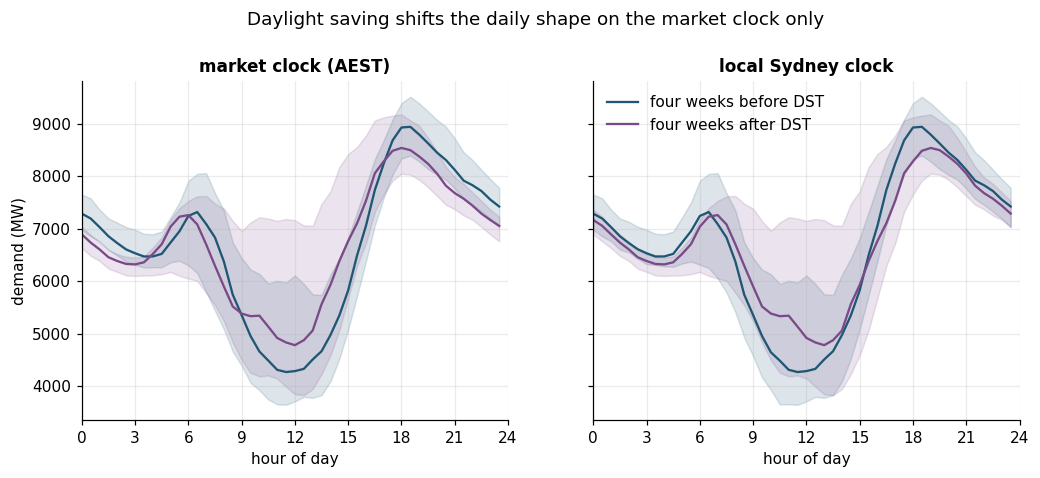

In [4]:
before_dst = demand.loc["2025-09-07":"2025-10-04"]
after_dst = demand.loc["2025-10-06":"2025-11-02"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, tz, title in (
    (axes[0], DISPLAY_TZ, "market clock (AEST)"),
    (axes[1], LOCAL_TZ, "local Sydney clock"),
):
    plot_clock_profile(ax, before_dst, tz, "four weeks before DST", palette("demand"))
    plot_clock_profile(ax, after_dst, tz, "four weeks after DST", palette("accent"))
    ax.set_title(title)
axes[0].set_ylabel("demand (MW)")
axes[1].legend()
fig.suptitle("Daylight saving shifts the daily shape on the market clock only", y=1.04)
save_figure(fig, "dst_daily_shape", cfg.paths.figures)
plt.show()

The hour-wide displacement on the left collapses on the right, confirming
both the timezone handling and the choice of clock for seasonal features.

### Cross-checking the demand-weather join

A timezone slip in either series would shift the demand-weather
relationship by hours, so the join is verified two ways.

**Temperature.** Correlating the raw series would mostly measure the phase
difference between two daily cycles (temperature peaks mid-afternoon,
demand peaks early evening), so the scan uses **anomalies**: each summer
series minus its own mean daily profile. A hot spell should lift demand
within a few hours, with demand trailing temperature (buildings and
behaviour integrate heat), so the peak should sit a little above zero lag
and nowhere near the ten hours a UTC-versus-AEST slip would produce.

**Irradiance.** Sunlight obeys astronomy: direct normal irradiance must be
zero through the local night and peak near local solar noon. This is an
exact, demand-free check of the weather clock.

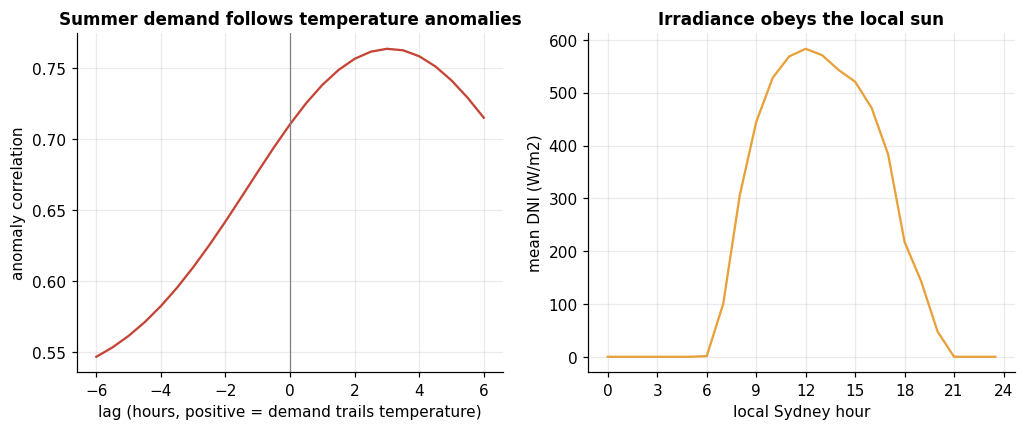

temperature anomaly correlation peaks at +3.0 h; DNI profile peaks at 12.0 local, night-time max 0.0 W/m2


In [5]:
summer = slice("2025-12-01", "2026-02-28")
temp_half_hourly = (
    era5["temperature_2m"].reindex(era5.index.union(grid)).interpolate("time").reindex(grid)
)
dni_half_hourly = (
    era5["direct_normal_irradiance"]
    .reindex(era5.index.union(grid))
    .interpolate("time")
    .reindex(grid)
)


def daily_anomaly(series: pd.Series) -> pd.Series:
    local_clock = series.index.tz_convert(LOCAL_TZ)
    step = local_clock.hour * 2 + local_clock.minute // 30
    return series - series.groupby(step).transform("mean")


demand_anomaly = daily_anomaly(demand.loc[summer])
temp_anomaly = daily_anomaly(temp_half_hourly.loc[summer])
lags = np.arange(-12, 13)
ccf = pd.Series([demand_anomaly.corr(temp_anomaly.shift(int(k))) for k in lags], index=lags / 2.0)

local_hour = dni_half_hourly.index.tz_convert(LOCAL_TZ).hour + (
    dni_half_hourly.index.tz_convert(LOCAL_TZ).minute / 60
)
dni_profile = dni_half_hourly.groupby(local_hour).mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ccf.index, ccf, color=palette("temperature"))
axes[0].axvline(0, color="grey", lw=0.8)
axes[0].set_xlabel("lag (hours, positive = demand trails temperature)")
axes[0].set_ylabel("anomaly correlation")
axes[0].set_title("Summer demand follows temperature anomalies")
axes[1].plot(dni_profile.index, dni_profile, color=palette("irradiance"))
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("mean DNI (W/m2)")
axes[1].set_xticks(np.arange(0, 25, 3))
axes[1].set_title("Irradiance obeys the local sun")
plt.show()

night = dni_half_hourly[
    np.isin(dni_half_hourly.index.tz_convert(LOCAL_TZ).hour, [22, 23, 0, 1, 2, 3])
]
print(
    f"temperature anomaly correlation peaks at {ccf.idxmax():+.1f} h; "
    f"DNI profile peaks at {dni_profile.idxmax():.1f} local, night-time max {night.max():.1f} W/m2"
)

The anomaly correlation peaks three hours after the temperature anomaly,
the right sign and size for thermal inertia and far from the ten-hour
displacement a timezone slip would produce. Irradiance is identically zero
at night and peaks within an hour of local solar noon, pinning the weather
clock exactly. (The demand-irradiance anomaly correlation is deliberately
not used here: sunshine suppresses demand through rooftop PV immediately
but raises it through heat a few hours later, and the competing channels
cancel near zero lag. That same confounding is why temperature and both
irradiance components all enter the feature set together.)

## What drives NSW1 demand

The window covers a full year plus a repeated autumn, so both seasons'
behaviour is visible. Demand carries a strong daily cycle, a weekly cycle
from working patterns, a U-shaped temperature response (heating below
roughly 17 C, cooling above roughly 20 C) and midday suppression from
rooftop solar.

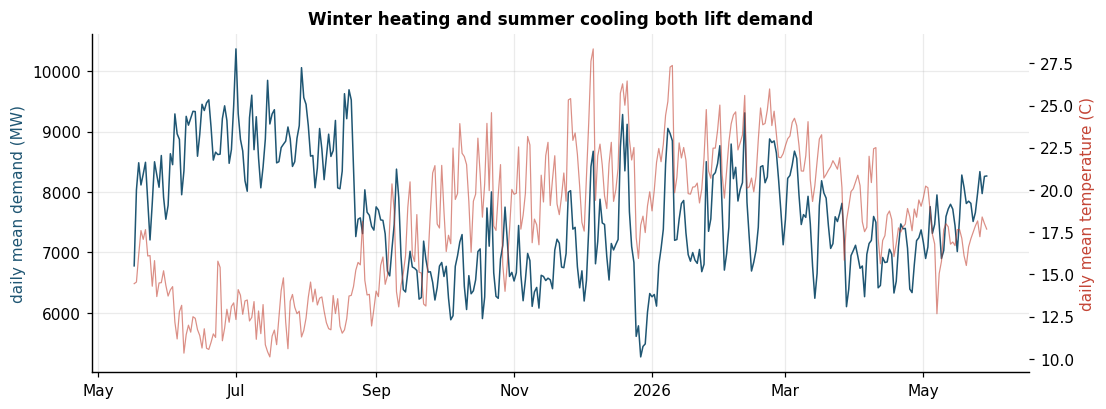

In [6]:
daily_mean = demand.resample("1D").mean()
daily_temp = temp_half_hourly.resample("1D").mean()

fig, ax = plt.subplots()
ax.plot(display_index(daily_mean.index), daily_mean, color=palette("demand"), lw=1.0)
ax.set_ylabel("daily mean demand (MW)", color=palette("demand"))
twin = ax.twinx()
twin.plot(
    display_index(daily_temp.index), daily_temp, color=palette("temperature"), lw=0.8, alpha=0.6
)
twin.set_ylabel("daily mean temperature (C)", color=palette("temperature"))
twin.grid(False)
format_date_axis(ax)
ax.set_title("Winter heating and summer cooling both lift demand")
plt.show()

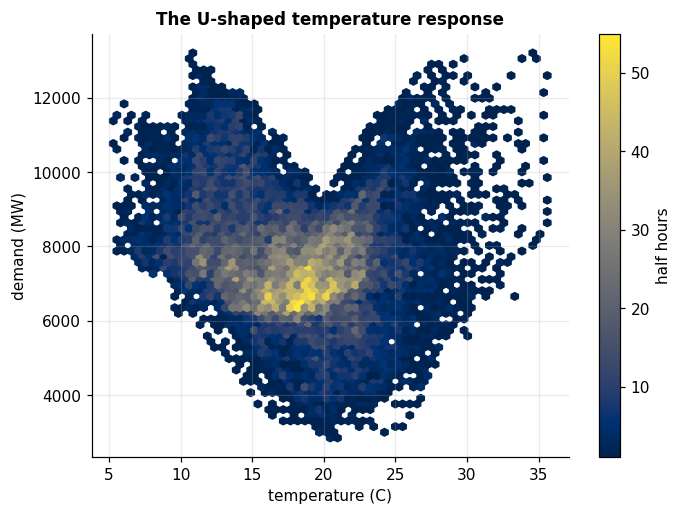

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(temp_half_hourly, demand, gridsize=60, cmap="cividis", mincnt=1)
ax.set_xlabel("temperature (C)")
ax.set_ylabel("demand (MW)")
ax.set_title("The U-shaped temperature response")
fig.colorbar(hb, label="half hours")
save_figure(fig, "demand_temperature", cfg.paths.figures)
plt.show()

The trough of the U sits around 17 to 20 C, supporting the configured
heating and cooling bases (16.5 and 20.5 C) for the degree-day features.
The vertical spread at any given temperature is the daily cycle, which the
seasonal basis carries.

Rooftop solar is the other defining feature of the modern NEM load shape.
Splitting days by midday irradiance shows the hollowed-out middle of the
day on sunny days; this is why direct and diffuse irradiance enter the
feature set alongside temperature.

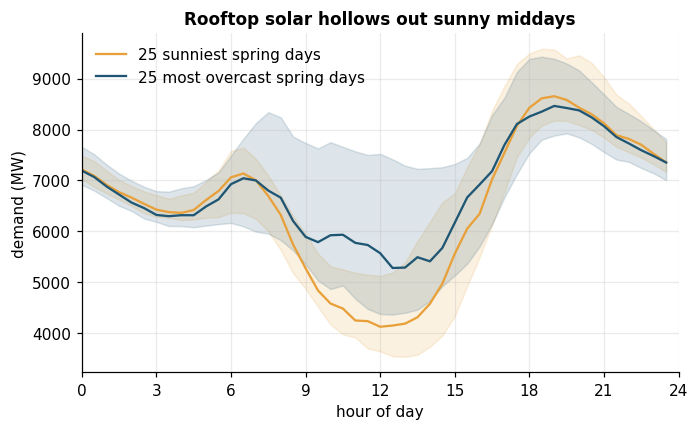

In [8]:
local = demand.index.tz_convert(LOCAL_TZ)
midday = (local.hour >= 10) & (local.hour < 14)
midday_dni = dni_half_hourly[midday].groupby(local[midday].date).mean()
spring = midday_dni.loc[
    (pd.to_datetime(midday_dni.index) >= "2025-09-01")
    & (pd.to_datetime(midday_dni.index) < "2025-12-01")
]
sunny = demand[np.isin(local.date, spring.nlargest(25).index)]
overcast = demand[np.isin(local.date, spring.nsmallest(25).index)]

fig, ax = plt.subplots(figsize=(7, 4))
plot_clock_profile(ax, sunny, LOCAL_TZ, "25 sunniest spring days", palette("irradiance"))
plot_clock_profile(ax, overcast, LOCAL_TZ, "25 most overcast spring days", palette("demand"))
ax.set_ylabel("demand (MW)")
ax.set_title("Rooftop solar hollows out sunny middays")
ax.legend()
save_figure(fig, "duck_curve", cfg.paths.figures)
plt.show()

The weekly cycle and the public holiday effect close out the calendar
structure: weekends and holidays drop the working-hours load, and holidays
behave like Sundays regardless of weekday, which motivates the holiday
indicator in the design matrix.

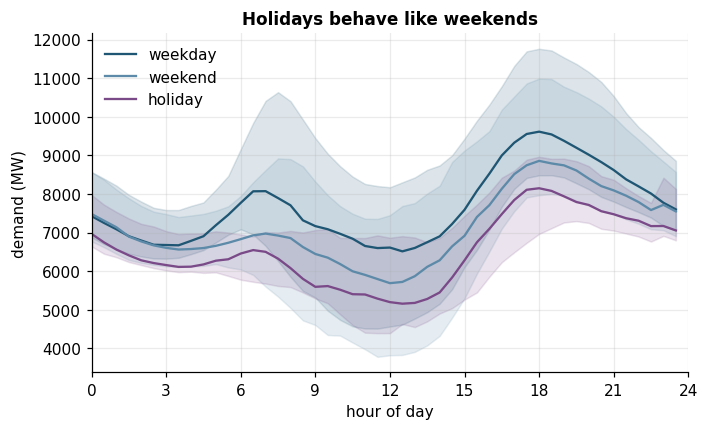

In [9]:
local_dow = demand.index.tz_convert(LOCAL_TZ).dayofweek
day_type = pd.Series(
    np.select(
        [holiday_flag(demand.index).to_numpy(), local_dow >= 5],
        ["holiday", "weekend"],
        default="weekday",
    ),
    index=demand.index,
)

fig, ax = plt.subplots(figsize=(7, 4))
for kind, colour in (
    ("weekday", palette("demand")),
    ("weekend", palette("forecast")),
    ("holiday", palette("accent")),
):
    plot_clock_profile(ax, demand[day_type == kind], DISPLAY_TZ, kind, colour)
ax.set_ylabel("demand (MW)")
ax.set_title("Holidays behave like weekends")
ax.legend()
plt.show()

## How good are the day-ahead weather forecasts?

The headline evaluation feeds the models the ECMWF IFS forecast exactly as
issued one day earlier, so its error against the ERA5 ground truth is part
of the story. Two caveats are acknowledged here rather than hidden. First,
coefficients are trained on ERA5 actuals while forecasts come from a
different model with its own climatology, a mild train/serve mismatch;
bias-correcting the forecast onto ERA5 is noted as future work. Second,
ERA5 itself is reanalysis, not station truth. The residual structure below
also calibrates the perturbation sweep used in notebook 05.

In [10]:
panel, report = build_panel(
    pl.read_parquet(cfg.paths.interim / "demand.parquet"), era5, forecast, cfg
)
residuals = pd.DataFrame(
    {
        "temperature (C)": panel["temp_fc_c"] - panel["temp_c"],
        "DNI (W/m2)": panel["dni_fc_wm2"] - panel["dni_wm2"],
    }
)
residuals.describe().loc[["mean", "std", "min", "max"]].T

,mean,std,min,max
temperature (C),-0.381526,1.097901,-7.199999,5.700001
DNI (W/m2),-27.130737,104.547958,-630.000000,739.800049


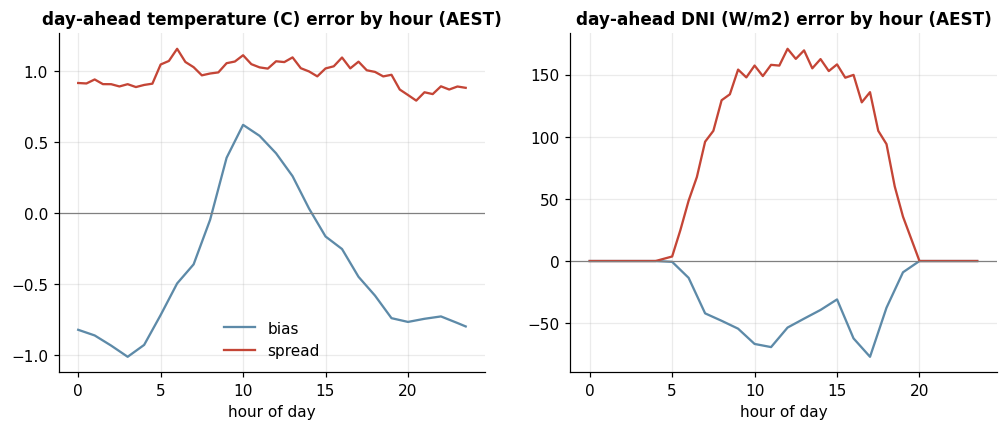

In [11]:
hour = panel.index.tz_convert(DISPLAY_TZ).hour + panel.index.tz_convert(DISPLAY_TZ).minute / 60
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, column in zip(axes, residuals.columns, strict=True):
    grouped = residuals[column].groupby(hour)
    ax.plot(grouped.mean().index, grouped.mean(), color=palette("forecast"), label="bias")
    ax.plot(grouped.std().index, grouped.std(), color=palette("temperature"), label="spread")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_title(f"day-ahead {column} error by hour (AEST)")
    ax.set_xlabel("hour of day")
axes[0].legend()
plt.show()

Temperature errors are roughly half a degree at night and around a degree
in the afternoon; irradiance errors concentrate in daylight hours as cloud
timing is the hard part. Both are small enough to leave clear weather
signal and large enough that perfect-foresight evaluation would flatter
every model, which is why both variants are scored in notebook 05.

## Cleansing

The panel build applies three guarded repairs, each counted and surfaced:
interpolation of demand gaps up to one hour, a Hampel screen (rolling
weekly median, eight scaled MADs) for telemetry spikes and interpolation of
short weather-forecast gaps with an actuals fallback for missing archive
runs. The thresholds are deliberately conservative: genuine demand peaks
are signal, not faults, and this window arrives clean from NEMWeb.

In [12]:
report.as_frame()

,column,repair,count
0,demand_mw,missing on grid,0
1,demand_mw,interpolated,0
2,demand_mw,outliers replaced,0
3,temp_fc_c,interpolated,0
4,dni_fc_wm2,interpolated,0
5,dhi_fc_wm2,interpolated,0
6,temp_fc_c,filled from actuals,0
7,dni_fc_wm2,filled from actuals,0
8,dhi_fc_wm2,filled from actuals,0


Nothing needed repair in this window. The screens stay in the pipeline
because reruns over future windows inherit them, and the zero counts are
themselves evidence the upstream feeds are curated.

## Chronological splits

Roughly 70/15/15 by whole market days, no shuffling: train teaches the
models, validation selects the ARIMA order and seasonal basis and test is
touched only by the final rolling-origin evaluation. The splits are written
as parquet and committed, so every later notebook starts from identical,
schema-validated data.

In [13]:
splits = chronological_split(panel.index, cfg.splits.train, cfg.splits.validation)
cfg.paths.processed.mkdir(parents=True, exist_ok=True)
for name, index in splits.items():
    panel.loc[index].to_parquet(cfg.paths.processed / f"{name}.parquet")
load_splits(cfg.paths.processed)
split_summary(splits)

,first,last,half_hours,days
split,,,,
train,2025-05-18 00:00:00+10:00,2026-02-05 23:30:00+10:00,12672,264.0
validation,2026-02-06 00:00:00+10:00,2026-04-03 23:30:00+10:00,2736,57.0
test,2026-04-04 00:00:00+10:00,2026-05-29 23:30:00+10:00,2688,56.0


## Summary

- The half-hourly grid is complete, duplicate-free and verified against
  the interval-ending-to-period-start and AEST-to-UTC conversions.
- Daily structure follows the local Sydney clock through daylight saving,
  so all seasonal features are built on local-clock phases.
- Lagged correlations place the demand-weather join within a couple of
  hours of zero, ruling out timezone slips.
- Demand shows daily, weekly and holiday structure, a U-shaped temperature
  response around a 17 to 20 C comfort band and solar suppression of
  midday load, motivating the configured feature set.
- Day-ahead forecast errors are material but modest, quantified here to
  calibrate the perturbation sweep.
- Train, validation and test splits are written, validated and committed.